In [49]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report

In [50]:
#Load Dataset
df = pd.read_csv(r"C:\Users\mssha\OneDrive\Desktop\ImpactSense\data\earthquake_week2_processed.csv")

print(df.shape)
print(df.columns)

(414, 6)
Index(['magnitude', 'depth', 'cdi', 'mmi', 'sig', 'alert'], dtype='object')


In [51]:
#Features & Target
X = df.drop("alert", axis=1)
y = df["alert"]

In [52]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [53]:
#Train Model
model = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=9,
    random_state=42
)

model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.03
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,9
,min_impurity_decrease,0.0
,init,None


In [55]:
#Prediction 
y_pred = model.predict(X_test)

In [56]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.927710843373494


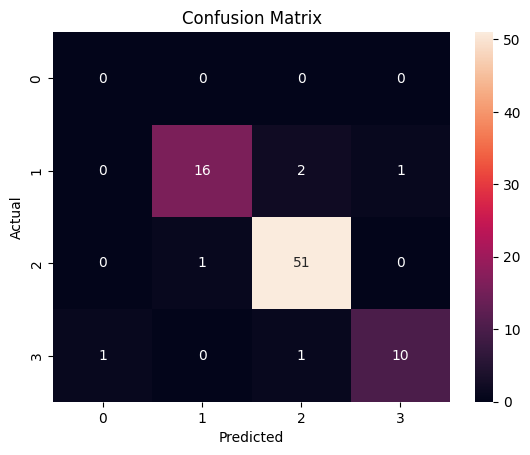

In [57]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [59]:
# MAE & MSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 0.10843373493975904
MSE: 0.20481927710843373


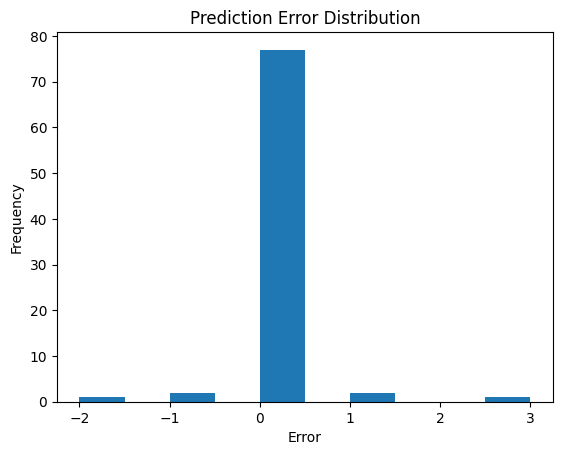

In [60]:
#Error Distribution Plot 
plt.figure()

errors = y_test - y_pred

plt.hist(errors)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

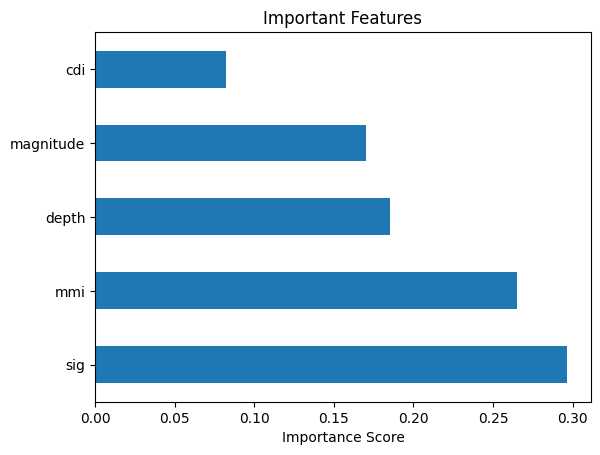

In [62]:
#Feature Importance 
importance = model.feature_importances_

feature_imp = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

plt.figure()

feature_imp.head(10).plot(kind="barh")

plt.title("Important Features")
plt.xlabel("Importance Score")

plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:11<00:00,  4.32it/s]


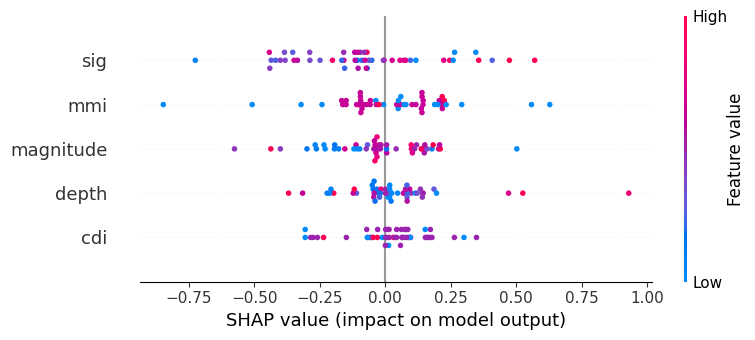

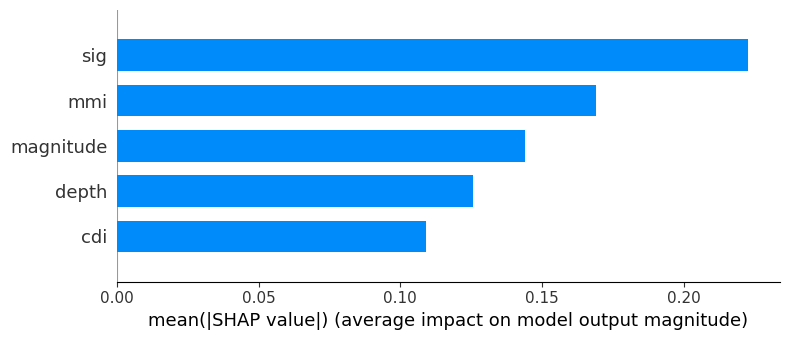

In [63]:
#SHAP Explainability

background = shap.sample(X_train, 100)

explainer = shap.KernelExplainer(
    model.predict,
    background
)

shap_values = explainer.shap_values(X_test[:50])

shap.summary_plot(shap_values, X_test[:50])

shap.summary_plot(
    shap_values,
    X_test[:50],
    plot_type="bar"
)

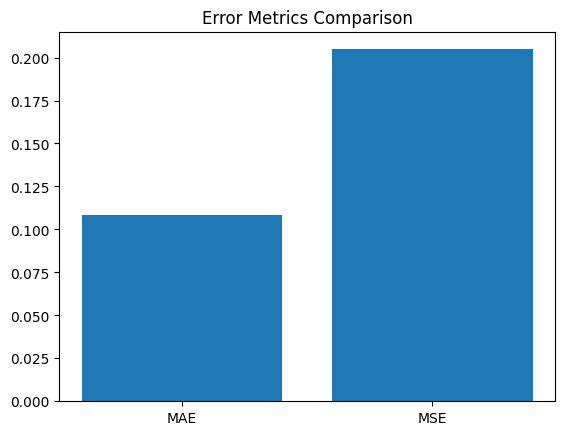

In [64]:
plt.figure()

plt.bar(["MAE","MSE"], [mae,mse])

plt.title("Error Metrics Comparison")

plt.show()

In [65]:
import joblib

joblib.dump(model, "impact_model.pkl")

['impact_model.pkl']